# Project FORESIGHT — Demand Forecasting
## Notebook 02: Seasonal-Naive Baseline Benchmark

**Client:** NorthBay Living  
**Deliverable:** D3 Forecasting Model & Backtest  
**Objective:** Establish the official, non-negotiable benchmark forecast using a genuine 52-week seasonal-naive baseline evaluated across chronological rolling origins.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from pathlib import Path

# Load weekly analysis-ready dataset
data_path = Path('../data/processed/weekly_demand_analysis_ready.csv')
df = pd.read_csv(data_path)
df['Week_Start'] = pd.to_datetime(df['Week_Start'])

# Standardize to 104 complete 7-day weeks (excluding partial 3-day week 105)
df = df[df['Week_Start'] < '2025-12-29'].sort_values(by=['SKU', 'Week_Start']).reset_index(drop=True)
unique_weeks = sorted(df['Week_Start'].unique())

print(f"Loaded clean dataset: {len(df):,} rows across {df['SKU'].nunique()} SKUs and {len(unique_weeks)} full weeks.")
print(f"Date range: {unique_weeks[0].strftime('%Y-%m-%d')} to {unique_weeks[-1].strftime('%Y-%m-%d')}")

Loaded clean dataset: 5,200 rows across 50 SKUs and 104 full weeks.
Date range: 2024-01-01 to 2025-12-22


### 1. The Seasonal-Naive Benchmark Formulation
In retail catalogs with seasonal patterns, the seasonal-naive model predicts that demand in future week $T+h$ equals the actual demand from the same week in the prior yearly seasonal cycle:

$$\hat{y}_{T+h}^{\text{baseline}} = y_{T+h - 52}$$

Because the forecast horizon is $h \in [1, 8]$ weeks and the seasonal lag is 52 weeks:
$$T + h - 52 \le T - 44 < T$$

This value is **always in the historical past**, ensuring **strictly zero data leakage**.

In [2]:
# Rolling-Origin Cross-Validation Setup (4 origins, 8-week horizon)
origins = [71, 79, 87, 95]
horizon = 8
season_period = 52

baseline_records = []
for orig_idx in origins:
    cutoff_date = unique_weeks[orig_idx]
    test_weeks = unique_weeks[orig_idx + 1 : orig_idx + horizon + 1]
    
    for h, tw in enumerate(test_weeks, 1):
        target_idx = orig_idx + h
        seasonal_date = unique_weeks[target_idx - season_period]
        
        actuals = df[df['Week_Start'] == tw][['SKU', 'Weekly_Units']].rename(columns={'Weekly_Units': 'Actual'})
        preds = df[df['Week_Start'] == seasonal_date][['SKU', 'Weekly_Units']].rename(columns={'Weekly_Units': 'Baseline_Pred'})
        
        merged = actuals.merge(preds, on='SKU')
        merged['Origin_Index'] = orig_idx
        merged['Origin_Date'] = cutoff_date.strftime('%Y-%m-%d')
        merged['Week_Start'] = tw.strftime('%Y-%m-%d')
        merged['Horizon_Step'] = h
        baseline_records.append(merged)

df_base_eval = pd.concat(baseline_records, ignore_index=True)

# Calculate global Weighted Absolute Percentage Error (WAPE)
total_actual = df_base_eval['Actual'].sum()
base_wape = np.sum(np.abs(df_base_eval['Actual'] - df_base_eval['Baseline_Pred'])) / total_actual
base_bias = np.mean(df_base_eval['Baseline_Pred'] - df_base_eval['Actual'])
base_mae = mean_absolute_error(df_base_eval['Actual'], df_base_eval['Baseline_Pred'])
base_rmse = root_mean_squared_error(df_base_eval['Actual'], df_base_eval['Baseline_Pred'])

print("=== SEASONAL-NAIVE BASELINE BACKTEST RESULTS ===")
print(f"Total Predictions Evaluated: {len(df_base_eval):,}")
print(f"Baseline WAPE: {base_wape:.4f} ({base_wape*100:.2f}%)")
print(f"Baseline Bias: {base_bias:.4f} units / SKU-week")
print(f"Baseline MAE:  {base_mae:.2f} units")
print(f"Baseline RMSE: {base_rmse:.2f} units")

=== SEASONAL-NAIVE BASELINE BACKTEST RESULTS ===
Total Predictions Evaluated: 1,600
Baseline WAPE: 0.1117 (11.17%)
Baseline Bias: 0.2806 units / SKU-week
Baseline MAE:  10.23 units
Baseline RMSE: 13.37 units


In [3]:
# Per-Origin Breakdown
orig_summary = []
for orig_idx in origins:
    sub = df_base_eval[df_base_eval['Origin_Index'] == orig_idx]
    wape = np.sum(np.abs(sub['Actual'] - sub['Baseline_Pred'])) / sub['Actual'].sum()
    bias = np.mean(sub['Baseline_Pred'] - sub['Actual'])
    orig_summary.append({
        'Origin_Index': orig_idx,
        'Origin_Date': sub['Origin_Date'].iloc[0],
        'Test_Start': sub['Week_Start'].min(),
        'Test_End': sub['Week_Start'].max(),
        'Baseline_WAPE_Pct': round(wape * 100, 2),
        'Baseline_Bias': round(bias, 2)
    })

display(pd.DataFrame(orig_summary))

,Origin_Index,Origin_Date,Test_Start,Test_End,Baseline_WAPE_Pct,Baseline_Bias
0,71,2025-05-12,2025-05-19,2025-07-07,10.04,0.40
1,79,2025-07-07,2025-07-14,2025-09-01,11.69,0.31
2,87,2025-09-01,2025-09-08,2025-10-27,11.37,0.20
3,95,2025-10-27,2025-11-03,2025-12-22,11.87,0.20


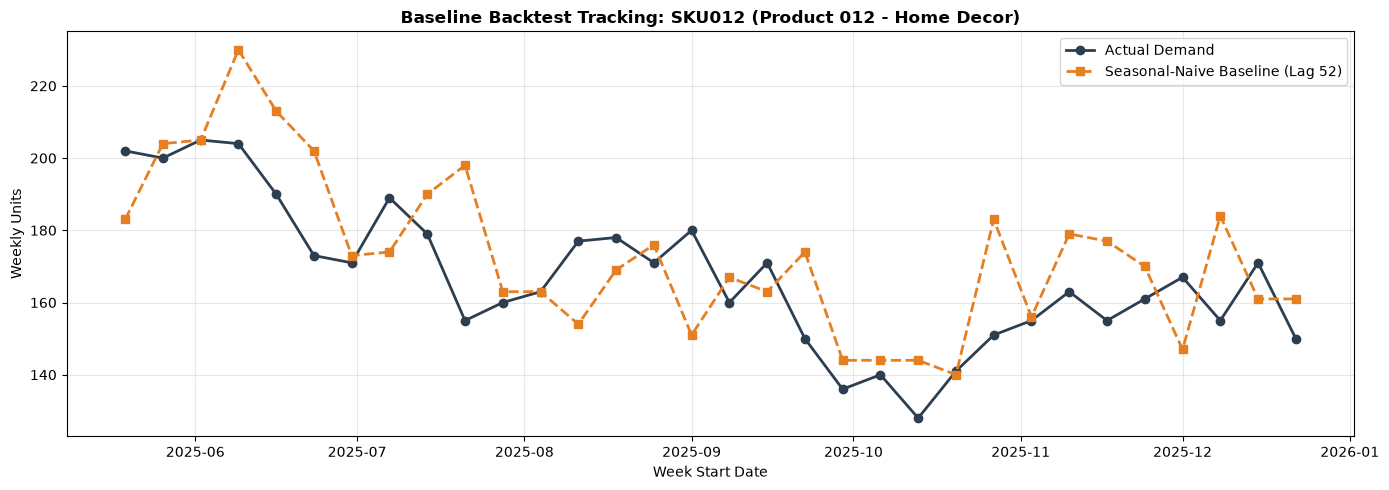

In [4]:
# Plot Actual vs Baseline for Top SKU
sku_sample = 'SKU012'
sample_df = df_base_eval[df_base_eval['SKU'] == sku_sample].sort_values(by='Week_Start')

plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(sample_df['Week_Start']), sample_df['Actual'], label='Actual Demand', color='#2c3e50', marker='o', lw=2)
plt.plot(pd.to_datetime(sample_df['Week_Start']), sample_df['Baseline_Pred'], label='Seasonal-Naive Baseline (Lag 52)', color='#e67e22', marker='s', ls='--', lw=2)
plt.title(f'Baseline Backtest Tracking: {sku_sample} (Product 012 - Home Decor)', fontsize=12, fontweight='bold')
plt.ylabel('Weekly Units')
plt.xlabel('Week Start Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()